# Optimizing hyperparameters

In [ ]:
# imports
import mne
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.model_selection import train_test_split, cross_val_score 
import warnings
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from toeplitzlda.classification import ToeplitzLDA
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import numpy as np
from tqdm import tqdm
import pickle

# utils functions
from .utils.preprocessing import load_complete_session, inspect_session, get_n_epochs, get_iteration_structure, get_n_iterations, load_session_chached, merge_sessions
from .utils.feature_extraction import get_jumping_means, epoch_vectorizer_channelprime
from .utils.offline_evaluation import compare_auc_single_trial_interval, compute_auc_with_cv
from .utils.online_simulation import online_simulation, online_adaptation_simulation_sw

# Turn off warnings (that most likely occur from ToeplitzLDA)
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
mne.set_log_level('WARNING')

In [ ]:
#all_patient_results = np.load("optimizing_hp_all_results")

### Time intervals (feature extraction)

#### function

In [2]:
def nested_cv(trials):
    # Time intervals
    print("Time intervals:")
    ival_bounds_100 = np.arange(0.1,0.51,0.1) # [0.1 0.2 0.3 0.4 0.5] (4)
    print(f"100 ms: \n{ival_bounds_100}")
    ival_bounds_50 = np.arange(0.1,0.51,0.05) # [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5] (8)
    print(f"50 ms: \n{ival_bounds_50}")
    ival_bounds_20 = np.arange(0.1,0.51,0.02) # [0.1  0.12 0.14 ... 0.46 0.48 0.5] (20)
    print(f"20 ms: \n{ival_bounds_20}")
    ival_bounds_10 = np.arange(0.12,0.5,0.01) # [0.12 0.13 0.14 ... 0.48 0.49 0.5] # might be changed
    print(f"10 ms: \n{ival_bounds_10}")

    # Nested cv settings
    ival_grid = [
                ival_bounds_100, 
                ival_bounds_50, 
                ival_bounds_20, 
                ival_bounds_10
                ]
    n_trials = len(trials)
    K_folds = 4
    fold_size = int(n_trials/K_folds)

    print(f"\nn_trials: {len(trials)}")
    print(f"Doing a {K_folds}-fold cross-vaidation:")
    print(f"There are {K_folds} folds each of size: {fold_size}")

    print("\nPerforming cross-validation...")

    ival_counter = 0
    ival_list = ["100 ms", "50 ms", "20 ms", "10 ms"]
    all_ival_scores = []

    for ival in ival_grid:
        outer_kf = KFold(n_splits=K_folds, shuffle=False)
        scores = np.zeros(4)
        nch = (trials[0][0]).info["nchan"]
        fold_counter = 0

        #for outer_fold_idx, (outer_train_idx, outer_test_idx) in enumerate(tqdm(outer_kf.split(trials), total=K_outer_folds, desc="CV")):
        for train_idx, test_idx in outer_kf.split(trials):

            X_train = [trials[i] for i in train_idx]  # | |x|x|x| for fold 1, |x| |x|x| for fold 2, ...
            X_test = [trials[i] for i in test_idx]    # |x| | | | for fold 1, | |x| | | for fold 2, ...

            # OUTER TEST using best ival
            X_train_complete, y_train_complete = epoch_vectorizer_channelprime(X_train,ival)
            X_test_complete, y_test_complete = epoch_vectorizer_channelprime(X_test, ival)

            # classifier
            clf_btlda_final = make_pipeline(
                ToeplitzLDA(n_channels=nch),
            )
            clf_btlda_final.fit(X_train_complete,y_train_complete)
            y_scores_test = clf_btlda_final.decision_function(X_test_complete)

            fold_score = roc_auc_score(y_test_complete, y_scores_test)
            scores[fold_counter] = fold_score
            fold_counter+=1

        print(f"\n Ival {ival_list[ival_counter]}")
        print(f"All folds scores: {scores}")
        print(f"Average AUC over all folds: {np.mean(scores):.4f}")
        all_ival_scores.append(scores)
        ival_counter+=1
        
    return all_ival_scores



#### Run procedure

In [12]:
# runtime: 7 mins
# Procedure: cross-validation for all patients

all_patient_results = dict() 

# for all patients
for i in range(1,10):
    print(f"Patient {i} -----------------------------------")
    # load data of sessions 1 and 2
    data_s1 = load_session_chached(f"B:/anonymized_data/P0{i}a/P{i}_S1/anonymized", 
                               selection = "6D_long_350", 
                               discard_channels=True)
    data_s2 = load_session_chached(f"B:/anonymized_data/P0{i}a/P{i}_S2/anonymized", 
                                selection = "6D_long_350", 
                                discard_channels=True)
    data_s12 = merge_sessions(data_s1, data_s2)
    trials = data_s12.get('trials')

    # perform nested cv
    outer_results = nested_cv(trials)

    # store results
    all_patient_results[f'P{i}_6D_long_350'] = outer_results

# patient 10:
print(f"Patient {10} -----------------------------------")
# load data of sessions 1 and 2
data_s1 = load_session_chached(f"B:/anonymized_data/P10a/P10_S1/anonymized", 
                            selection = "6D_long_350", 
                            discard_channels=True)
data_s2 = load_session_chached(f"B:/anonymized_data/P10a/P10_S2/anonymized", 
                            selection = "6D_long_350", 
                            discard_channels=True)
data_s12 = merge_sessions(data_s1, data_s2)
trials = data_s12.get('trials')

# perform nested cv
outer_results = nested_cv(trials)

# store results
all_patient_results[f'P10_6D_long_350'] = outer_results

Patient 1 -----------------------------------
Loading file:  B:_anonymized_data_P01a_P1_S1_anonymized
Corresponding .pkl file:  B:_anonymized_data_P01a_P1_S1_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P01a_P1_S1_anonymized6D_long_350_dc.pkl
Loading file:  B:_anonymized_data_P01a_P1_S2_anonymized
Corresponding .pkl file:  B:_anonymized_data_P01a_P1_S2_anonymized6D_long_350_dc.pkl
A .pkl file already exists. Loading the data from B:_anonymized_data_P01a_P1_S2_anonymized6D_long_350_dc.pkl
Time intervals:
100 ms: 
[0.1 0.2 0.3 0.4 0.5]
50 ms: 
[0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]
20 ms: 
[0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3  0.32 0.34 0.36
 0.38 0.4  0.42 0.44 0.46 0.48 0.5 ]
10 ms: 
[0.12 0.13 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25
 0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39
 0.4  0.41 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49]

n_trials: 30
Doing a 4-fold cross

In [ ]:
all_patient_results = np.load('optim_hyperparam_6D_long_350.npy', allow_pickle=True)


AttributeError: 'numpy.ndarray' object has no attribute 'keys'

Grand average of 100 ms: 0.6416624750039517
Grand average of 50 ms: 0.6461541458460867
Grand average of 20 ms: 0.6414945036652003
Grand average of 10 ms: 0.637407463525084


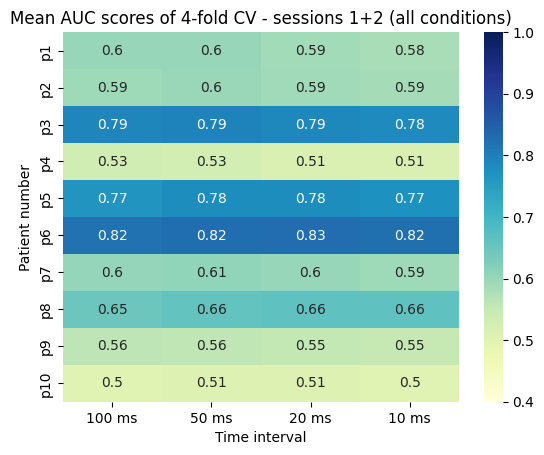

In [18]:
# Results

import seaborn as sns

# Histogram 1 --------------------------------------

# all_scores = []
# for patient in all_patient_results.keys():
#     patient_list = []
#     for fold in all_patient_results.get(patient):
#         patient_list.append(fold.get('score'))
#     all_scores.append(patient_list)

sns.heatmap(fold_means_array,vmin=0.4,vmax=1,annot=True, yticklabels=['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10'], cmap="YlGnBu", xticklabels=['100 ms', '50 ms', '20 ms', '10 ms'])
plt.ylabel("Patient number")
plt.xlabel("Time interval")
plt.title("Mean AUC scores of 4-fold CV - sessions 1+2 (all conditions)")

# Print results
#print(fold_means_array.shape)
print(f"Grand average of 100 ms: {np.mean(fold_means_array, axis=0)[0]}")
print(f"Grand average of 50 ms: {np.mean(fold_means_array, axis=0)[1]}")
print(f"Grand average of 20 ms: {np.mean(fold_means_array, axis=0)[2]}")
print(f"Grand average of 10 ms: {np.mean(fold_means_array, axis=0)[3]}")



# # Histogram 2 --------------------------------------

# all_folds_list = []
# for patient in all_patient_results.keys():
#     fold_list = []
#     for fold in all_patient_results.get(patient):
#         fold_list.append(((fold.get('best_ival')[1] - fold.get('best_ival')[0])))
#     all_folds_list.append(fold_list)

# sns.heatmap(all_folds_list,vmin=0.01,vmax=0.15,center=0.03,annot=True,yticklabels=['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10'], cbar=True, cmap="coolwarm", ax=axs[1])
# axs[1].set_xlabel("outer fold of the nested cv")
# axs[1].set_title("best time interval per fold")
# plt.suptitle("Heatmap per patient: each block is the outcome of a fold")
# plt.show()

### Selection of sessions

In [74]:
# runtime: 
# Procedure: cross-validation for all patients

all_patient_results_6D_long_350 = dict() 

# for all patients
for i in range(1,11):
    print(f"Patient {i} -----------------------------------")
    if i < 10:
        number = f"0{i}"

    # load data of sessions 1 and 2
    data_s1 = load_session_chached(
                               #data_path = f"data_p{i}/P{i}_S1/anonymized", 
                               session_path = f"B:/anonymized_data/P{number}a/P{i}_S1/anonymized",
                               selection = "6D_long_350", 
                               discard_channels=True)
    data_s2 = load_session_chached(
                               #data_path = f"data_p{i}/P{i}_S2/anonymized",
                               session_path = f"B:/anonymized_data/P{number}a/P{i}_S2/anonymized", 
                               selection = "6D_long_350", 
                               discard_channels=True)
    data_s12 = merge_sessions(data_s1, data_s2)
    trials = data_s12.get('trials')
    del data_s1, data_s2, data_s12

    # perform nested cv
    outer_results = nested_cv(trials)

    # store results
    all_patient_results_6D_long_350[f'P{i}'] = outer_results

Patient 1 -----------------------------------
Loading file:  B:_anonymized_data_P01a_P1_S1_anonymized
Corresponding .pkl file:  B:_anonymized_data_P01a_P1_S1_anonymized6D_long_350_dc.pkl
A .pkl file does not exist yet. Loading the data and creating B:_anonymized_data_P01a_P1_S1_anonymized6D_long_350_dc.pkl... (this might take a few mins)
['6D', '6D']
['long', 'long']
All conditions of the selected runs of this session:  True
Number of iterations per trial:
Run 1: [15. 15. 15. 15. 15. 15.]
Run 2: [15. 15. 15. 15. 15. 15.]
Loaded files: ['P1_S1/anonymized/auditoryAphasia_6D_long_350_Block1_Run1.vhdr', 'P1_S1/anonymized/auditoryAphasia_6D_long_350_Block2_Run1.vhdr']
Loading file:  B:_anonymized_data_P01a_P1_S2_anonymized
Corresponding .pkl file:  B:_anonymized_data_P01a_P1_S2_anonymized6D_long_350_dc.pkl
A .pkl file does not exist yet. Loading the data and creating B:_anonymized_data_P01a_P1_S2_anonymized6D_long_350_dc.pkl... (this might take a few mins)
['6D', '6D', '6D']
['long', 'long'

IndexError: list index out of range

In [ ]:
fold_means_6D_long_350 = []

counter = 1
for i in all_patient_results:
    if counter == 10:
        print(all_patient_results.get(i))
        print(np.array(all_patient_results.get(i)))
        print(np.array(np.mean(all_patient_results.get(i),axis=1)))

    #print(np.mean(np.array(all_patient_results.get(i)),axis=1))
    fold_means.append(np.mean(np.array(all_patient_results.get(i)),axis=1))
    counter+=1


#np.save("optimizing_hyperparams_new", all_patient_results)
fold_means_array = np.array(fold_means)